# UnDirect multı layer network adding 

In [ ]:
conda deactivate # if you use conde firstable deactive conda 

In [3]:
import numpy as np
import pandas as pd
import math
import numpy as np
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as img
#import snap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
#import seaborn as sn
import math
import warnings
from collections import deque
from heapq import heappop, heappush
from itertools import count
from networkx.algorithms.shortest_paths.weighted import _weight_function
from networkx.utils import py_random_state
from networkx.utils.decorators import not_implemented_for
from numpy.random import randint
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx.algorithms.isomorphism as iso

----------------------------HIGHWAY LAYER


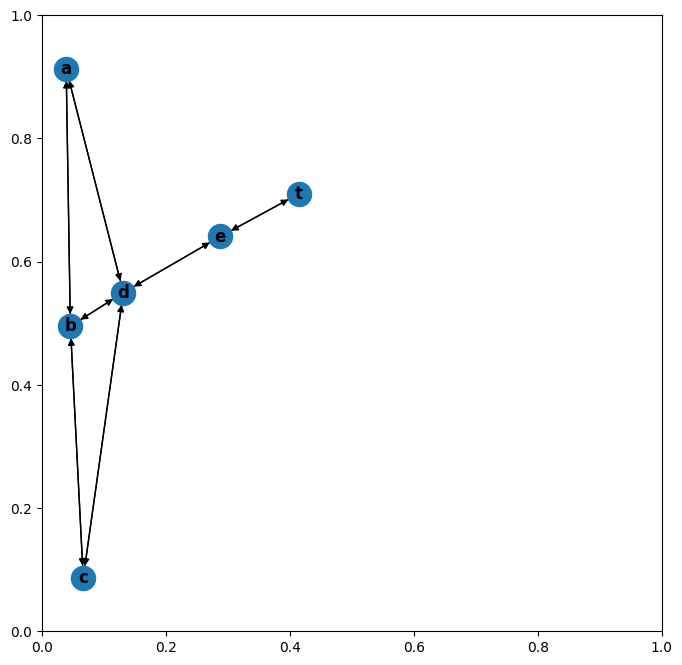

In [6]:
C=nx.DiGraph()
C_copy=nx.DiGraph()
E=nx.DiGraph()
E_Copy=nx.DiGraph()
F=nx.DiGraph()
C.add_weighted_edges_from([("t", "e", 1.0), ("e", "d", 1.0),("d", "a", 1.0), ("d", "c", 1.0),("a", "b", 1.0),("c", "b", 1.0), ("b","d",2.1),("e", "t", 1.0), ("d", "e", 1.0),("a", "d", 1.0), ("c", "d", 1.0),("b", "a", 1.0),("b", "c", 1.0), ("d","b",2.1)]) #


E.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0), (2,1, 1.0), (3, 2, 1.0),(1, 3, 1.0), (4, 3, 1.0),( "b",4, 1.0),( "t",1, 1.0)])
E_Copy.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0), (2,1, 1.0), (3, 2, 1.0),(1, 3, 1.0), (4, 3, 1.0),( "b",4, 1.0),( "t",1, 1.0)])
C_copy.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(2,1, 1.0), (3, 2, 1.0),(1, 3, 1.0), (4, 3, 1.0)])
F.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0), (2,1, 1.0), (3, 2, 1.0),(1, 3, 1.0), (4, 3, 1.0),( "b",4, 1.0),( "t",1, 1.0)])
plt.subplots(figsize=(8,8))
plt.subplot(121)
#nx.draw(C, with_labels=True, font_weight='bold')
print("----------------------------HIGHWAY LAYER")
nx.draw(C, with_labels=True, font_weight='bold')

-----------------METRO LAYER


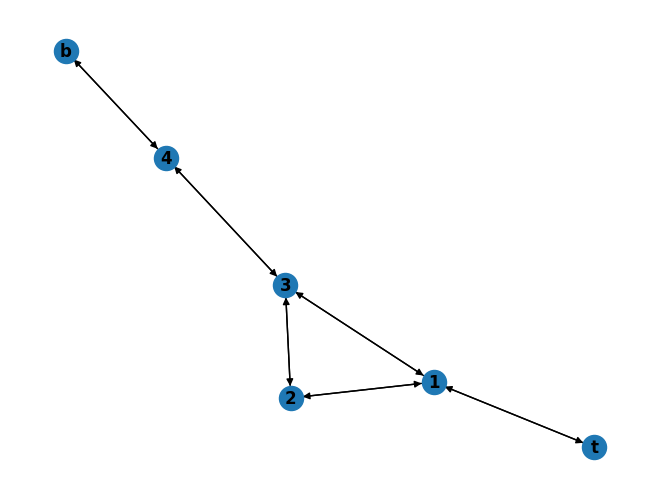

In [9]:
print( "-----------------METRO LAYER")

nx.draw(E, with_labels=True, font_weight='bold')

 ------------------------MULTI LAYER METRO AND HIGHWAY 


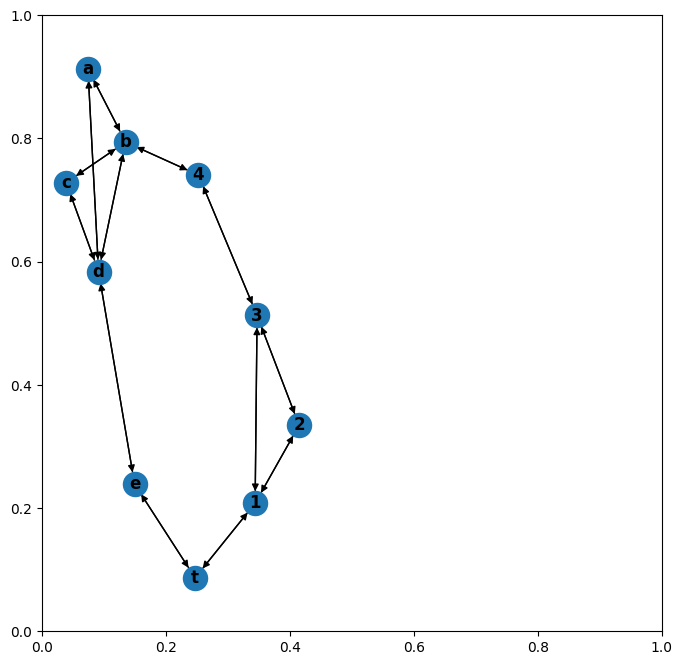

In [10]:
F.add_edges_from(C.edges)
plt.subplots(figsize=(8,8))
plt.subplot(121)
print(" ------------------------MULTI LAYER METRO AND HIGHWAY ")
nx.draw(F, with_labels=True, font_weight='bold')

In [14]:
def decode(bounds, n_bits, bitstring, budget): # GENERATES AN INTEGER BETWEEN THE GENE SENT AND THE DESIRED LIMITS
    decoded = list()
    largest = 2**n_bits  # Because it's a 32 gene, it makes 32   
    for i in range(len(bounds)): # Returns i in this 32 in bound 2 so i 0 becomes 1  

        start, end = i * n_bits, (i * n_bits)+n_bits # for example i=0 for 0 to 16 for i=0 i 1 for 16 to 32 i 2 cannot be because of the number in the box 

        substring = bitstring[start:end] # Since the incoming pop is also 32, there are two sets as 0 16 and 16 32  
    
        chars = ''.join([str(s) for s in substring])  # merging all lanes

    
        integer = int(chars, 2) # for example 10011, then 19 is found by adding the values 2 over 0 2 over 1 and 2 over 2 over 4 
      
        value = bounds[i][0] + (integer/largest) * (bounds[i][1] - bounds[i][0]) 
            
        decoded.append(round(value))
        
    return(decoded)

In [17]:
# tournament selection
def selection(pop, scores, k=3):
    # first random selection
    selection_ix = randint(len(pop))
    for ix in randint(0, len(pop), k-1):
        # check if better (e.g. perform a tournament)
        if scores[ix] < scores[selection_ix]:
            selection_ix = ix
    return pop[selection_ix]


In [20]:
# crossover two parents to create two children
def crossover(p1, p2, r_cross):
# children are copies of parents by default
    c1, c2 = p1.copy(), p2.copy()
    # check for recombination
    if rand() < r_cross:
        # select crossover point that is not on the end of the string
        pt = randint(1, len(p1)-2)
        # perform crossover
        c1 = p1[:pt] + p2[pt:]
        c2 = p2[:pt] + p1[pt:]
    return [c1, c2]

In [23]:
# mutation operator
def mutation(bitstring, r_mut): # mutation(c, r_mut)
    for i in range(len(bitstring)):
        # check for a mutation
        if rand() < r_mut:
            # flip the bit
            bitstring[i] = 1 - bitstring[i]

In [26]:
# genetic algorithm
def genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut,budget,E,C,C_copy,alfa):
    # initial population of random bitstring
    pop = [randint(0, 2, n_bits*len(bounds)).tolist() for _ in range(n_pop)] # A 32 bar code consisting of 0 and 1
    # keep track of best solution

    best, best_eval = 0, objective(decode(bounds, n_bits, pop[0],budget),E,C,C_copy,alfa) # objective 2 digits must enter 32 barcode by sending the decode first
    # enumerate generations
    for gen in range(n_iter): # continues until the desired iteration.
        # decode population
        decoded = [decode(bounds, n_bits,p,budget) for p in pop]# sends two values between the upper and lower limit.
        # evaluate all candidates in the population
        scores = [objective(x,E,C,C_copy,alfa) for x in decoded] # sends these binary values to x[0]**2.0 + x[1]**2.0 to get a value.
        # Adds any possible link to the current network and gives the standard deviation of betwenles.
        # check for new best solution COMPARES THE RESULTS FROM THE PREVIOUS ITERATION BELOW.
        for i in range(n_pop): # We have defined a population of 100 that will take values for different pairs 100 times and compare each result 
            if scores[i] < best_eval:# is less than the first value K  
                best, best_eval = pop[i], scores[i] # best score in the best pop where the house is ranked number one 
                print(">%d, new best f(%s) = %f" % (gen,  decoded[i], scores[i]))# print if there is a change in best  
        # select parents
        selected = [selection(pop, scores) for _ in range(n_pop)] # pop 100 times and send the value to selection select the best of the tournament i.e. each iteration
        # create the next generation Create new binary edge suggestions to create a new binary pair.
        children = list()  # create a list called childeren
        for i in range(0, n_pop, 2): # Here it's going to be double, jumping 2 by 2
            # get selected parents in pairs
            p1, p2 = selected[i], selected[i+1] # Generate the best of two consecutive iterations according to the top two binary preferences for new edge selection
            # crossover and mutation
            for c in crossover(p1, p2, r_cross):  #0,9 cros over  ratio
                # mutation
                mutation(c, r_mut)
                # store for next generation
                children.append(c) # Now we have a new couple 
        # replace population
        pop = children #new series of 100 We have a list of 100 different binary edge proposals for the next iteration. does this for the number of iterations
        # regenerates sets of edges at each iteration. ver adds each edge to the initial mesh to produce a standard deviation value.
    return [best, best_eval]

In [29]:
def objective(x,E,C,C_copy,alfa): # here x sends a binary, e.g. a [0,3], between the desired range 0 and 3.  C lower disconnected layer C upper layer E lower connected layer  
    MLB={}
    B=[]
    for b in range(len(E.edges)):
        B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))

    #x=[1,3]

    layer1=nx.edge_betweenness_centrality(C,weight="weight")
    l5=[]
    l6=[]
    for i in range(round((len(x)/2))):

        l5.append(x[2*i])

        l6.append(x[2*i+1])

    decoded=list(zip(l5,l6))
    decoded1=list(zip(l5,l6))

    s=list(C_copy.edges) # disconnected state of the substrate
    v=[]
    for i in range (len(s)):
        v.append((s[i][0],s[i][1]))
    if len(list(dict.fromkeys( decoded1)))!=len( decoded1):  #IT WOULD BE COSTLY IF THE TWO NUMBERS SENT ARE THE SAME, FOR EXAMPLE (3,1) (3,1)
        return(15) # BIG   M cost
    # else:



    for i in range(round((len(x)/2))): 

        if decoded[i] in s:
            decoded1.remove(decoded[i])   # RESENDING EXISTING CONNECTIONS
            return(15)
        elif decoded[i][0]==decoded[i][1]: # not offer node such (1,1) (2,2) or (3,3)
            decoded1.remove(decoded[i])
            return(15)
        #elif (decoded[i][1],decoded[i][0]) in s:
            #decoded1.remove(decoded[i])   # for DIRECT GRAPH for non-directional means look in the opposite direction 
            #return(15)
        #elif get_number_of_elements(decoded[i] ,decoded )>1:
            #return(15)

        else: 
            new=[]
           #g=[]
            for l in range (len(decoded1)):
                new.append((decoded1[l][0], decoded1[l][1], nx.shortest_path_length (E,source=decoded1[l][0],target=decoded1[l][1])*0.7)) # We assume that the new weight is 0.7 less than the existing short path.
# Since it is a weighted network, the weight is assigned to the proposed edge by assuming that the path with the new addition will be 0.7 shorter than the existing route.
            #g= list(E.edges())+new # üst katman bağlantıları ve alt katman ağırlıksız 
            B=[]
            for b in range(len(E.edges)): # alt katman bağlantılı 
                B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))

            R=nx.DiGraph()
            P=nx.DiGraph()

            R.add_weighted_edges_from(B)

            P.add_weighted_edges_from(B)

                   # new substrate here layer 2 will be recalculated
            #R=nx.Graph()
            #R.clear

            R.add_weighted_edges_from(new)
            P.add_weighted_edges_from(new)

            layer2=nx.edge_betweenness_centrality(P,weight="weight")
            sources= list(P.nodes())
            targets= list(C.nodes())
            R.add_edges_from(C.edges)
            layer1_2=nx.edge_betweenness_centrality_subset(R,  sources,targets, normalized=False, weight="weight") #NODE İÇİN ,
            list1=list(layer1.keys())
            list2=list(layer2.keys())
            listgeneric=list(layer1_2.keys())

            for i in list(R.nodes):# merged network node list
                for j in list(R.nodes): 
                    if (i,j)  in listgeneric: # if edge i j exists in the combined layer list 
                        if (i,j) in list1:  # Multiply inter and intra if the edge exists in the first layer
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
                        if (j,i) in list1:  # Multiply by inter and intra if the inverse of the edge exists in the first layer
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)
                        if (i,j) in list2:  # If the edge i,j is present in the second layer, multiply the combined layer by the second layer 
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
                        if (j,i) in list2:# j,i multiply the layer merged with the second layer if the edge exists in the second layer 
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa)     
            F=R
            F.add_edges_from(C.edges)
            layer1_2=nx.edge_betweenness_centrality(F,weight="weight")




    # return(np.std(list(MLB.values()))) #  for all network 

    H=[]
    for h in list(C.edges):
        H.append(MLB[h])
    return(np.std(H))#  only upper layer  

 

In [32]:
# define range for input
alfa=0.8
budget=3
bounds = [[1.0, 4.0], [1.0, 4.0]]*budget #in this space interval 
# define the total iterations
n_iter = 100 #
# bits per variable
n_bits = 8 # In the form of 16 barcodes
# define the population size
n_pop = 100
# crossover rate
r_cross = 0.15
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
best, score = genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut, budget ,E,C,C_copy,alfa)
print('Done!')
#print( best,score)
decoded = decode(bounds, n_bits, best,budget)
print('f(%s) = %f' % (decoded, score))

>9, new best f([1, 4, 4, 2, 4, 1]) = 0.589072
>66, new best f([1, 4, 2, 4, 4, 1]) = 0.573843
Done!
f([1, 4, 2, 4, 4, 1]) = 0.573843


# Output 

In [36]:
x = [(decoded[i], decoded[i+1]) for i in range(0, len(decoded), 2)] # if buget more than 1 
#x= decoded # if budget 1 
new=[]
MLB={}
B=[]
layer1=nx.edge_betweenness_centrality(C,weight="weight")
for l in range (len(x)):
    new.append((x[l][0], x[l][1], nx.shortest_path_length (E_Copy,source=x[l][0],target=x[l][1])*0.7)) # We assume that the new weight is 0.7 less than the existing short path.
 
    
   
    for b in range(len(E_Copy.edges)): # alt katman bağlantılı 
        B.append((list(E_Copy.edges.data())[b][0],list(E_Copy.edges.data(b))[b][1],list(E_Copy.edges.data())[b][2]["weight"]))
    
    R=nx.DiGraph()
    P=nx.DiGraph()
    
    R.add_weighted_edges_from(B)
    
    P.add_weighted_edges_from(B)
    
           # new substrate here layer 2 will be recalculated
    #R=nx.Graph()
    #R.clear
    
    R.add_weighted_edges_from(new)
    P.add_weighted_edges_from(new)
    layer2=nx.edge_betweenness_centrality(P,weight="weight")
    sources= list(P.nodes())
    targets= list(C.nodes())
    R.add_edges_from(C.edges)
    layer1_2=nx.edge_betweenness_centrality_subset(R,  sources,targets, normalized=False, weight="weight") #NODE İÇİN ,
    list1=list(layer1.keys())
    list2=list(layer2.keys())
    listgeneric=list(layer1_2.keys())
    
    for i in list(R.nodes):# merged network node list
        for j in list(R.nodes): 
            if (i,j)  in listgeneric: # if edge i j exists in the combined layer list 
                if (i,j) in list1:  # Multiply inter and intra if the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
                if (j,i) in list1:  # Multiply by inter and intra if the inverse of the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)
                if (i,j) in list2:  # If the edge i,j is present in the second layer, multiply the combined layer by the second layer 
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
                if (j,i) in list2:# j,i multiply the layer merged with the second layer if the edge exists in the second layer 
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa)     
    F=R
    F.add_edges_from(C.edges)
    layer1_2=nx.edge_betweenness_centrality(F,weight="weight")




# return(np.std(list(MLB.values()))) #  for all network 

    H=[]
    for h in list(C.edges):
        H.append(MLB[h])
print(np.std(H))#  only upper layer  



0.5738425202921424


In [38]:
MLB

{(1, 2): 0.05333333333333334,
 (1, 't'): 1.733333333333333,
 (1, 3): 0.05333333333333334,
 (1, 4): 0.7066666666666666,
 (2, 1): 0.45333333333333325,
 (2, 3): 0.08000000000000002,
 ('t', 1): 0.13333333333333333,
 ('t', 'e'): 1.933333333333333,
 (3, 1): 0.45333333333333325,
 (3, 2): 0.02666666666666667,
 (3, 4): 0.9066666666666665,
 (4, 3): 0.05333333333333334,
 (4, 'b'): 3.3333333333333326,
 ('b', 4): 0.13333333333333333,
 ('b', 'd'): 1.3999999999999997,
 ('b', 'a'): 1.0799999999999998,
 ('b', 'c'): 1.0799999999999998,
 ('e', 't'): 0.33333333333333326,
 ('e', 'd'): 1.2133333333333332,
 ('d', 'b'): 0.19999999999999996,
 ('d', 'e'): 0.8133333333333332,
 ('d', 'a'): 0.33333333333333326,
 ('d', 'c'): 0.33333333333333326,
 ('a', 'b'): 0.08000000000000002,
 ('a', 'd'): 0.13333333333333333,
 ('c', 'b'): 0.08000000000000002,
 ('c', 'd'): 0.13333333333333333,
 (2, 4): 0.8533333333333332,
 (4, 1): 0.30666666666666664}

In [40]:
list(MLB.values())

[0.05333333333333334,
 1.733333333333333,
 0.05333333333333334,
 0.7066666666666666,
 0.45333333333333325,
 0.08000000000000002,
 0.13333333333333333,
 1.933333333333333,
 0.45333333333333325,
 0.02666666666666667,
 0.9066666666666665,
 0.05333333333333334,
 3.3333333333333326,
 0.13333333333333333,
 1.3999999999999997,
 1.0799999999999998,
 1.0799999999999998,
 0.33333333333333326,
 1.2133333333333332,
 0.19999999999999996,
 0.8133333333333332,
 0.33333333333333326,
 0.33333333333333326,
 0.08000000000000002,
 0.13333333333333333,
 0.08000000000000002,
 0.13333333333333333,
 0.8533333333333332,
 0.30666666666666664]

In [42]:
#New standart deviation for 1 layer highway 
np.std(list(MLB.values()))

np.float64(0.7334150496754893)

In [43]:
H # only upper 

[1.933333333333333,
 1.2133333333333332,
 0.33333333333333326,
 0.33333333333333326,
 0.33333333333333326,
 0.8133333333333332,
 0.19999999999999996,
 0.08000000000000002,
 0.13333333333333333,
 0.08000000000000002,
 0.13333333333333333,
 1.3999999999999997,
 1.0799999999999998,
 1.0799999999999998]

In [46]:
np.std(H) # only upper highway SD

np.float64(0.5738425202921424)

# If you calculate all layer 

In [359]:
def objective(x,E,C,C_copy,alfa): # here x sends a binary, e.g. a [0,3], between the desired range 0 and 3.  C lower disconnected layer C upper layer E lower connected layer  
    MLB={}
    B=[]
    for b in range(len(E.edges)):
        B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))

    #x=[1,3]

    layer1=nx.edge_betweenness_centrality(C,weight="weight")
    l5=[]
    l6=[]
    for i in range(round((len(x)/2))):

        l5.append(x[2*i])

        l6.append(x[2*i+1])

    decoded=list(zip(l5,l6))
    decoded1=list(zip(l5,l6))

    s=list(C_copy.edges) # disconnected state of the substrate
    v=[]
    for i in range (len(s)):
        v.append((s[i][0],s[i][1]))
    if len(list(dict.fromkeys( decoded1)))!=len( decoded1):  #IT WOULD BE COSTLY IF THE TWO NUMBERS SENT ARE THE SAME, FOR EXAMPLE (3,1) (3,1)
        return(15) # BIG   M cost
    # else:



    for i in range(round((len(x)/2))): 

        if decoded[i] in s:
            decoded1.remove(decoded[i])   # RESENDING EXISTING CONNECTIONS
            return(15)
        elif decoded[i][0]==decoded[i][1]: # not offer node such (1,1) (2,2) or (3,3)
            decoded1.remove(decoded[i])
            return(15)
        #elif (decoded[i][1],decoded[i][0]) in s:
            #decoded1.remove(decoded[i])   # for DIRECT GRAPH for non-directional means look in the opposite direction 
            #return(15)
        #elif get_number_of_elements(decoded[i] ,decoded )>1:
            #return(15)

        else: 
            new=[]
           #g=[]
            for l in range (len(decoded1)):
                new.append((decoded1[l][0], decoded1[l][1], nx.shortest_path_length (E,source=decoded1[l][0],target=decoded1[l][1])*0.7)) # We assume that the new weight is 0.7 less than the existing short path.
# Since it is a weighted network, the weight is assigned to the proposed edge by assuming that the path with the new addition will be 0.7 shorter than the existing route.
            #g= list(E.edges())+new # üst katman bağlantıları ve alt katman ağırlıksız 
            B=[]
            for b in range(len(E.edges)): # alt katman bağlantılı 
                B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))

            R=nx.DiGraph()
            P=nx.DiGraph()

            R.add_weighted_edges_from(B)

            P.add_weighted_edges_from(B)

                   # new substrate here layer 2 will be recalculated
            #R=nx.Graph()
            #R.clear

            R.add_weighted_edges_from(new)
            P.add_weighted_edges_from(new)

            layer2=nx.edge_betweenness_centrality(P,weight="weight")
            sources= list(P.nodes())
            targets= list(C.nodes())
            R.add_edges_from(C.edges)
            layer1_2=nx.edge_betweenness_centrality_subset(R,  sources,targets, normalized=False, weight="weight") #NODE İÇİN ,
            list1=list(layer1.keys())
            list2=list(layer2.keys())
            listgeneric=list(layer1_2.keys())

            for i in list(R.nodes):# merged network node list
                for j in list(R.nodes): 
                    if (i,j)  in listgeneric: # if edge i j exists in the combined layer list 
                        if (i,j) in list1:  # Multiply inter and intra if the edge exists in the first layer
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
                        if (j,i) in list1:  # Multiply by inter and intra if the inverse of the edge exists in the first layer
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)
                        if (i,j) in list2:  # If the edge i,j is present in the second layer, multiply the combined layer by the second layer 
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
                        if (j,i) in list2:# j,i multiply the layer merged with the second layer if the edge exists in the second layer 
                            MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa)     
            F=R
            F.add_edges_from(C.edges)
            layer1_2=nx.edge_betweenness_centrality(F,weight="weight")




    return(np.std(list(MLB.values())))
 

 

In [363]:
# define range for input
alfa=0.8
budget=3
bounds = [[1.0, 4.0], [1.0, 4.0]]*budget #in this space interval 
# define the total iterations
n_iter = 100 #
# bits per variable
n_bits = 8 # In the form of 16 barcodes
# define the population size
n_pop = 100
# crossover rate
r_cross = 0.15
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
best, score = genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut, budget ,E,C,C_copy,alfa)
print('Done!')
#print( best,score)
decoded = decode(bounds, n_bits, best,budget)
print('f(%s) = %f' % (decoded, score))

>15, new best f([4, 1, 1, 4, 4, 2]) = 0.746062
>60, new best f([4, 1, 4, 2, 2, 4]) = 0.739388
Done!
f([4, 1, 4, 2, 2, 4]) = 0.739388


In [366]:
x = [(decoded[i], decoded[i+1]) for i in range(0, len(decoded), 2)] # if buget more than 1 
#x= decoded # if budget 1 
new=[]
MLB={}
B=[]

for l in range (len(x)):
    new.append((x[l][0], x[l][1], nx.shortest_path_length (E_Copy,source=x[l][0],target=x[l][1])*0.7)) # We assume that the new weight is 0.7 less than the existing short path.
 
    
   
    for b in range(len(E_Copy.edges)): # alt katman bağlantılı 
        B.append((list(E_Copy.edges.data())[b][0],list(E_Copy.edges.data(b))[b][1],list(E_Copy.edges.data())[b][2]["weight"]))
    
    R=nx.DiGraph()
    P=nx.DiGraph()
    
    R.add_weighted_edges_from(B)
    
    P.add_weighted_edges_from(B)
    
           # new substrate here layer 2 will be recalculated
    #R=nx.Graph()
    #R.clear
    
    R.add_weighted_edges_from(new)
    P.add_weighted_edges_from(new)
    layer2=nx.edge_betweenness_centrality(P,weight="weight")
    sources= list(P.nodes())
    targets= list(C.nodes())
    R.add_edges_from(C.edges)
    layer1_2=nx.edge_betweenness_centrality_subset(R,  sources,targets, normalized=False, weight="weight") #NODE İÇİN ,
    list1=list(layer1.keys())
    list2=list(layer2.keys())
    listgeneric=list(layer1_2.keys())
    
    for i in list(R.nodes):# merged network node list
        for j in list(R.nodes): 
            if (i,j)  in listgeneric: # if edge i j exists in the combined layer list 
                if (i,j) in list1:  # Multiply inter and intra if the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(i,j)])*alfa)
                if (j,i) in list1:  # Multiply by inter and intra if the inverse of the edge exists in the first layer
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer1[(j,i)])*alfa)
                if (i,j) in list2:  # If the edge i,j is present in the second layer, multiply the combined layer by the second layer 
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(i,j)])*alfa)
                if (j,i) in list2:# j,i multiply the layer merged with the second layer if the edge exists in the second layer 
                    MLB[(i,j)]=(layer1_2[(i,j)]*(1-alfa)+(layer2[(j,i)])*alfa)     
    F=R
    F.add_edges_from(C.edges)
    layer1_2=nx.edge_betweenness_centrality(F,weight="weight")




print(np.std(list(MLB.values()))) #  for all network 

0.7393879698483069


In [369]:
MLB

{(1, 2): 0.05333333333333334,
 (1, 't'): 1.933333333333333,
 (1, 3): 0.45333333333333325,
 (2, 1): 0.45333333333333325,
 (2, 3): 0.02666666666666667,
 ('t', 1): 0.13333333333333333,
 ('t', 'e'): 2.133333333333333,
 (3, 1): 0.5599999999999999,
 (3, 2): 0.02666666666666667,
 (3, 4): 1.253333333333333,
 (4, 1): 0.30666666666666664,
 (4, 3): 0.16000000000000003,
 (4, 'b'): 3.1333333333333324,
 ('b', 4): 0.13333333333333333,
 ('b', 'd'): 1.3999999999999997,
 ('b', 'a'): 0.9799999999999998,
 ('b', 'c'): 0.9799999999999998,
 ('e', 't'): 0.33333333333333326,
 ('e', 'd'): 1.413333333333333,
 ('d', 'b'): 0.19999999999999996,
 ('d', 'e'): 0.8133333333333332,
 ('d', 'a'): 0.43333333333333324,
 ('d', 'c'): 0.43333333333333324,
 ('a', 'b'): 0.08000000000000002,
 ('a', 'd'): 0.13333333333333333,
 ('c', 'b'): 0.08000000000000002,
 ('c', 'd'): 0.13333333333333333,
 (4, 2): 0.05333333333333334,
 (2, 4): 0.8533333333333332}

In [371]:
list(MLB.values())

[0.05333333333333334,
 1.933333333333333,
 0.45333333333333325,
 0.45333333333333325,
 0.02666666666666667,
 0.13333333333333333,
 2.133333333333333,
 0.5599999999999999,
 0.02666666666666667,
 1.253333333333333,
 0.30666666666666664,
 0.16000000000000003,
 3.1333333333333324,
 0.13333333333333333,
 1.3999999999999997,
 0.9799999999999998,
 0.9799999999999998,
 0.33333333333333326,
 1.413333333333333,
 0.19999999999999996,
 0.8133333333333332,
 0.43333333333333324,
 0.43333333333333324,
 0.08000000000000002,
 0.13333333333333333,
 0.08000000000000002,
 0.13333333333333333,
 0.05333333333333334,
 0.8533333333333332]

In [373]:
#New standart deviation for 1 layer highway 
np.std(list(MLB.values()))

np.float64(0.7393879698483069)